In [22]:
# environment: /glade/work/dkimpara/conda-envs/goes

In [23]:
import s3fs as s3
import xarray as xr
import shutil

import os
import glob
import numpy as np

import matplotlib.pyplot as plt
import cartopy.crs as ccrs


In [24]:
latlon_ds = xr.open_dataset("/glade/work/dkimpara/goes-cloud-data/goes19_abi_full_disk_lat_lon.nc")

# get a ABI file

In [77]:
fs = s3.S3FileSystem(anon=True)


instrument, sector = 'ABI-L1b','RadF-Reproc'
year = "2019"
day = "334"
hour = "13"

ins_sec = instrument + '-' + sector

files = fs.ls('s3://noaa-goes16/' + ins_sec + '/' + year + '/'+ day +'/'+ hour)
channels = [13]

channel_files = []

for channel in channels:
    channel_files += [file for file in files if f"C{channel:02}" in file]

file = channel_files[1]
with fs.open(file) as f:
    ds = xr.open_dataset(f).load()


In [69]:
def convert_to_brightness_temp(ds):
    ds["BT"] = (ds["planck_fk2"] /
            np.log(ds["planck_fk1"] / np.clip(ds["Rad"], 1e-6, None) + 1) -
            ds["planck_bc1"]
               ) / ds["planck_bc2"]

    return ds

def convert_to_reflectance(ds):
    if ds["kappa0"].isnull():
        raise ValueError("kappa0 is NaN")
        
    ds["Reflectance"] = ds["kappa0"] * ds["Rad"]

    return ds

# get projection specs

In [5]:
projection_lat = ds.goes_imager_projection.latitude_of_projection_origin
projection_lon = ds.goes_imager_projection.longitude_of_projection_origin
perspective_point_height = ds.goes_imager_projection.perspective_point_height / 1000
semi_major_axis = ds.goes_imager_projection.semi_major_axis / 1000

# compute local zenith angle

In [6]:
H = perspective_point_height + semi_major_axis

In [7]:
beta = np.arccos(np.cos(np.deg2rad(latlon_ds.latitude - projection_lat)) *
                np.cos(np.deg2rad(latlon_ds.longitude - projection_lon))
                )
lza = np.arcsin(H * np.sin(beta) / 
               np.sqrt(H ** 2 + semi_major_axis ** 2 - 2 * H * semi_major_axis * np.cos(beta))
               )

In [8]:
lza_deg = np.rad2deg(lza)

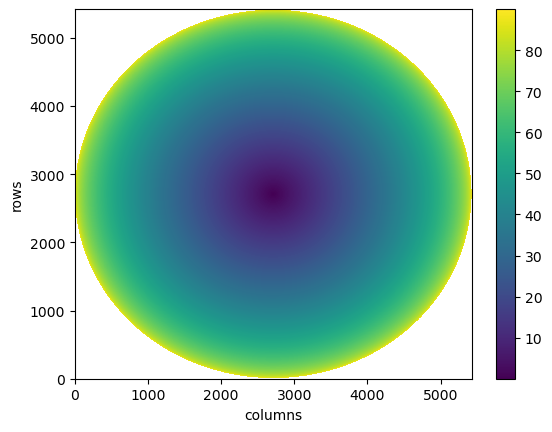

In [9]:
lza_deg.plot()

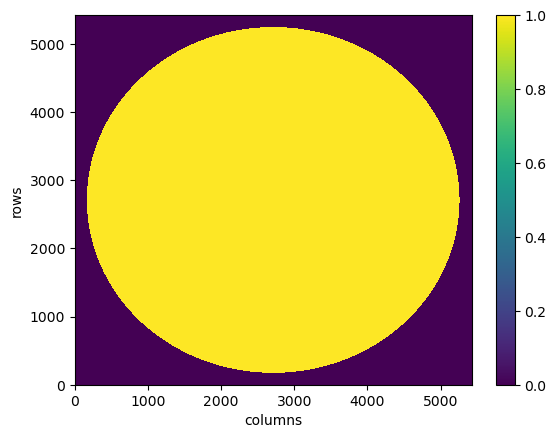

In [10]:
(lza_deg < 70).plot()

In [4]:
#lza_deg.to_netcdf("/glade/work/dkimpara/goes-cloud-data/goes_e_abi_full_disk_lza.nc")

lza_deg = xr.open_dataarray("/glade/work/dkimpara/goes-cloud-data/goes_e_abi_full_disk_lza.nc")
latlon_ds["LZA"] = lza_deg
latlon_ds.to_netcdf("/glade/work/dkimpara/goes-cloud-data/goes_e_abi_full_disk_latlon_lza.nc")

In [12]:
lza_deg

<xarray.DataArray (rows: 5424, columns: 5424)> Size: 235MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(5424, 5424))
Dimensions without coordinates: rows, columns